# Week-8: ADS-B

## Automatic Dependent Surveillance-Broadcast (ADS-B)

The following text is adapted from (https://github.com/bistromath/gr-air-modes).

__Mode S__ is the transponder protocol used in modern commercial aircraft.
A Mode S-equipped aircraft replies to radar interrogation by either
ground radar (Secondary Surveillance Radar, or **SSR**) or other aircraft ("Traffic
Collision Avoidance System", or **TCAS**).

![alt text](./nbimages/ADSB_System.png "ADS-B General Overview")

__Automatic Dependent Surveillance-Broadcast (ADS-B)__ is a communication
protocol using the Extended Squitter capability of the Mode S transport
layer.  The protocol is:

* __Automatic__: it requires no pilot input
* __Dependent__: it is dependent on altimeter, GPS, and other aircraft
  instrumentation for information
* __Surveillance__: it provides current information about the transmitting
  aircraft
* __Broadcast__: it is one-way, broadcast to all receivers within range.

ADS-B-equipped aircraft broadcast ("squitter") their position, velocity,
flight number, and other interesting information to any receiver within
range of the aircraft. Position reports are typically generated once per
second and flight indentification every five seconds.

ADS-B is an __Secondary Surveillance Radar__ system. Traditional radars are large, expensive and old. And radar coverage may be limited by distance, terrain and atmospheric conditions. 

## ADS-B: A Digital Signal
Packets are sent at **1090MHz** and use **Pulse Position Modulation (PPM)** at a rate of **1Mbit per second**. The simple modulation scheme is designed to be transceived by cheap hardware -- which is very much what we are doing in this lab!

Pulse position modulation belongs to the family of amplitude-modulated signals and in particular to the class of amplitude-shift-keying (ASK) or on-off-keying (OOK). In OOK, `0`, `1` bits are sent by turning the carrier on and off. PPM uses the [Manchester](http://en.wikipedia.org/wiki/Manchester_code) encoding variant of OOK. The idea in **Machester encoding** is that in each bit interval there is always a transition between on and off and the transition occurs in the middle of the bit interval. For example, a transition from off to on would represent a `0` and a transition from on to off would represent a `1`. Manchester codes have the advantage of being **self clocking** so the clock timing can be recovered from the data stream. 

A Mode S ADS-B packet consists of an $8\mu$s preamble followed by a data block of 56 or 112 $\mu$s. A **preamble** is a signal used in communications to synchronize transmission timing between two or more systems. Here's a diagram that illustrates a typical packet:


<img src="./nbimages/adsb-packet.png" alt="Drawing" style="height: 200px;"/>

Now, since the bit-rate is 1Mbit/s, a sampling rate of 2MS/s should be sufficient to capture the bit transitions, detect the preamble and decode packets. In practice, ADS-B packets can be decoded using the rtl-sdr, but the captured data does not look like the ideal packet. Here's an example part of a captured packet:

<img src="./nbimages/real_adsb_packet.png" alt="Drawing" style="height: 200px;"/>

As you can see, there are many __distortions__: the key-off is not zero and there are variations in the amplitudes of the key-on. These come from various sources including the anti-aliasing filters, interfering signals, noise, automatic gain control and more. However, it is possible to clearly see the preamble and the packet bit content! This is pretty amazing that this can be done using a $40 USB dongle because ADS-B equipment is very expensive (up to thousands of dollars).

There are several types and subtypes of "squitters":

* __Short__ squitters are 56bits (8bits control, 24bits address, 24bits parity check)
* __Long__ squitters are 112bits (8bits control, 24bits address, 56bits ADS message, 24bits parity)

Only the long squitters have location information in them. 

## ADS-B Aggregators
Since ADSB is public, many web sites aggregate the ADSB data from a wide range of sites to provide
real time information about where flights are, and the flight paths they have taken. Two are
Flightaware.com and Flightradar24.com. This is very useful.
<img src="./nbimages/flight_radar24.png" alt="Drawing" />

Table below lists several ADS-B networks.

| Name | Type | Founded | Number of receivers |
|------|------|--|--|
|FlightAware|Commercial|2005|30,000+|
|FlightRadar24|Commercial|2006|25,000+|
|RadarBox24|Commercial|2007|15,000+|
|OpenSky network|Non-profit/research|2013|3,500+|
|ADS-B Exchange|Non-profit|2016|5,000+|

## Pegasus Airlines' 100th Aircraft, Cumhuriyet
Pegasus Airlines took delivery of its 100th aircraft. The new Airbus A321neo, bearing the tail sign TC-RDP, completed its inaugural journey from Hamburg, Germany, landing at Istanbul Sabiha Gökçen Airport on Saturday, 30 September 2023, at 6pm. 

As part of the 100th anniversary celebrations of Republic Day, Pegasus Airlines' 100th anniversary aircraft carried out a special flight with the flight code PC-100C. Flight PC-100C, which took off from Sabiha Gökçen Airport in Istanbul at 10.30, followed a flight route in the skies of Ankara, forming the number '100'. Citizens who followed the plane via the flight radar application were able to see the number 100 over Ankara.'100' was drawn in the air during Pegasus' 100th anniversary special flight. Below is my screenshot showing its special path on 26th October, 2023.  
<img src="./nbimages/flight_radar_pegasus_100.png" alt="Drawing" />

Later, I came across 'Cumhuriyet' airplane at Sabiha Gökçen Airport by chance. I didn't miss to to take a photo for you!

<img src="./nbimages/PGS_Cumhuriyet.jpg" alt="Drawing" />

### ADS-B Walkthrough Example

Consider example record given in your repo, `rtl_adsb.dat`. This file has been recorded using RTL-SDR set to **1090 MHz** at a rate of **3.2Msps**, ie 3200000 samples per second. 

In [1]:
import os
file_name = 'rtl_adsb.dat'
number_of_samples = os.path.getsize(file_name) / 2
print("Record contains " + str(int(number_of_samples)) + " complex samples and this corresponds to " + str(number_of_samples / 3200000) + " seconds data. ")

Record contains 16000000 complex samples and this corresponds to 5.0 seconds data. 


We are using the same Python function to **load** complex IQ data. 

In [2]:
def RTLSDRLoadRecord(file_name):
    import numpy as np
    data = np.fromfile(file_name, np.uint8)
    # change it to complex data
    data_c = data[::2] + 1j * data[1::2]
    # remove offset
    return data_c - (127 + 1j * 127)

In [3]:
# load data
data = RTLSDRLoadRecord('rtl_adsb.dat');

We are only concerned with the envelope, so we take the **absolute** value.  

In [4]:
# we are only interested in magnitudes
data_abs = abs(data);

We'll **upsample** to 4 MHz to make the bit boundaries line up with the samples.

In [5]:
# resample so that multiple of 2Msps
from scipy import signal
data_res = signal.resample(data_abs, int(16000000 * 5 / 4))

Plot the magnitude of the received signal. Each **spike** is an ADS-B packet!

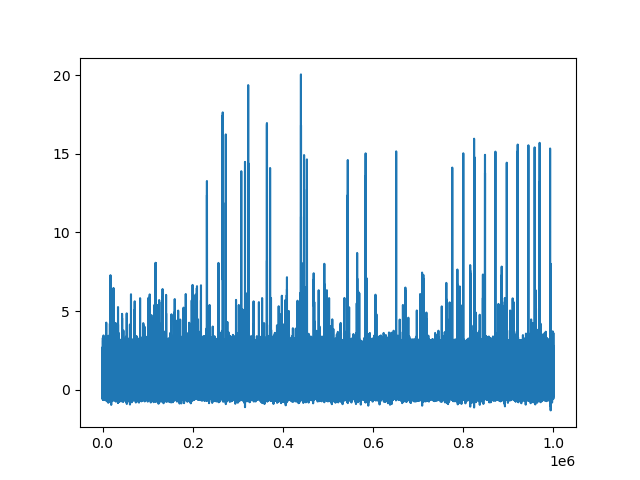

In [6]:
import matplotlib.pyplot as plt
%matplotlib widget
plt.plot(data_res[1:1000000]);

Inspect just an example packet shown below. You can clearly see the **preamble** and the data bits. 

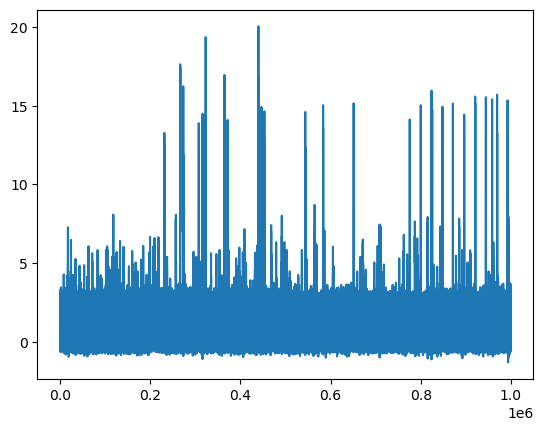

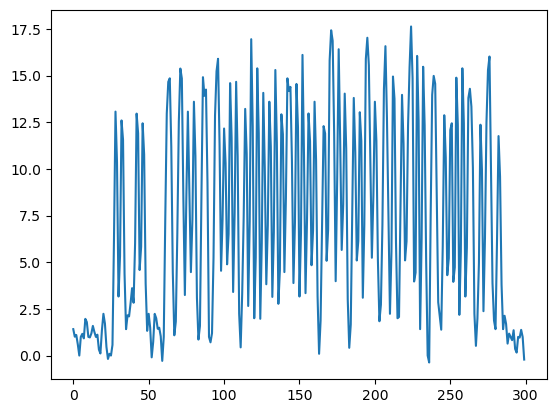

In [7]:
%matplotlib inline
plt.figure()
packet = data_res[266300:266600];
plt.plot(packet);

If we take the 4 MHz sampled data and **threshold** it we get the ADSB waveform. 

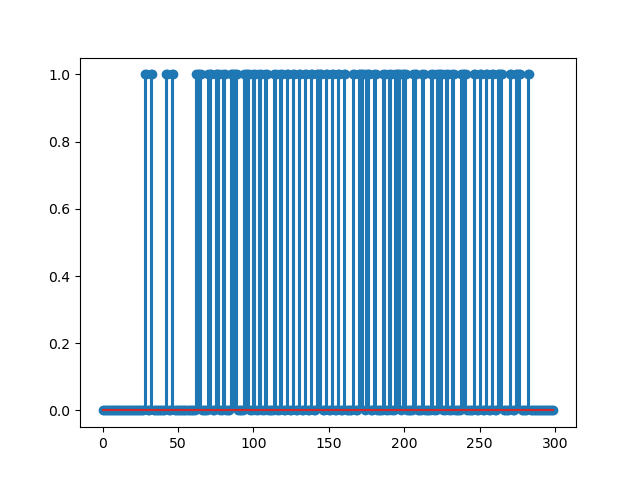

In [8]:
packet_thr = packet > 8.5;
%matplotlib widget
plt.stem(packet_thr);

Then **subsampling** by a factor of 2 and **shifting** to the first non-zero bit, we get the ADSB bit stream
for the packet.

In [9]:
import numpy as np
%matplotlib widget
packet_sub = packet_thr[::2]
plt.stem(packet_sub);
start = np.where(packet_sub==1);
ind = start[0][0]
print(ind)

14


We can even decode by eye. First detect the preamble, first 16 bits: `1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0`

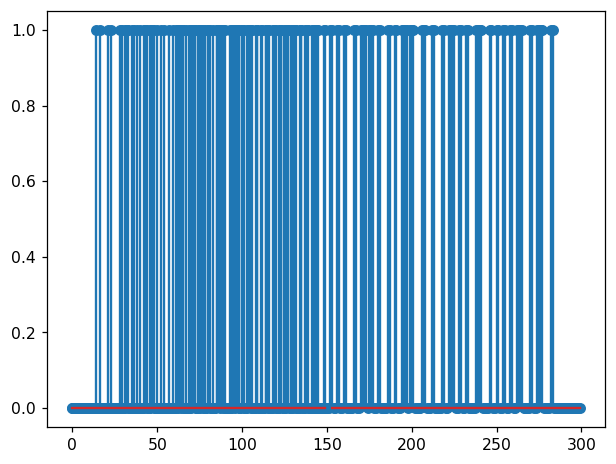

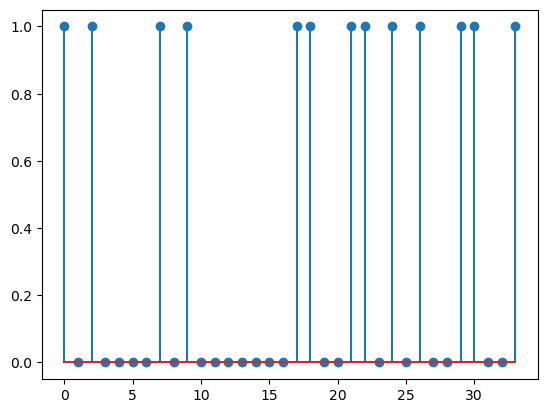

In [10]:
%matplotlib inline
plt.figure()
plt.stem(packet_sub[ind:ind+34]);

## Mode S format
The following text is adapted from https://mode-s.org/decode/content/introduction.html

The Mode S communication protocol is designed to handle different types of uplink and downlink message formats. The first five bits of the message define the uplink format (UF) or downlink format (DF) number of the message. Based on the UF/DF number, different structures of the data block are presented. Table below shows all available Mode S formats. Currently, 11 Mode S formats are being used. Numbers not in this table are reserved for future use.

| UF/DF | Bits | Uplink type | Downlink type |
|------|------|--|--|
| 0	|56|Short air-air surveillance (ACAS)|Short air-air surveillance (ACAS)|
| 4	|56|Surveillance, altitude request|Surveillance, altitude reply|
| 5	|56|Surveillance, identity request|Surveillance, identity reply|
| 11|56|Mode S All-Call|All-Call reply|
| 16|112|Long air-air surveillance (ACAS)|Long air-air surveillance (ACAS)|
| 17|112|-|Extended squitter|
| 18|112|-|Extended squitter/non transponder|
| 19|112|-|Military extended squitter|
| 20|112|Comm-A, altitude request|Comm-B, altitude reply|
| 21|112|Comm-A, identity request|Comm-B, identity reply|
| 24|112|Comm-C (ELM)|Comm-D (ELM)|

This time let's **decode data bits** of the previous example message. First 5 data bits are `0 1 0 1 1` so this is Mode-S All-Call reply message as can be found from the table above. 
<img src="./nbimages/mode_s_11.png" alt="Mode-S" />

In this lab we will be looking for **Extended Squitter** messages. We'll restrict our attention to finding packets with the flight numbers of the planes. Each plane sends these out every 2 seconds. The bits in the 112 $\mu$s ADSB packet are allocated as follows: 

| Bit | No. bits | Abbreviation | Information |
|------|------|--|--|
|1–5|5|DF|Downlink Format|
|6–8|3|CA|Transponder capability|
|9–32|24|ICAO|ICAO aircraft address|
|33–88|56|ME|Message, extended squitter|
|(33–37)|(5)|(TC)|(Type code)|
|89–112|24|PI|Parity/Interrogator ID|

The first 5 bits after the preamble identify the type of packet. This will be 17 or 18 for planes communicating to the ground. We are only interested in the DF 17 packets. The next three bits tell something about where the plane is, we'll skip these.

The unique identifier for the plane is the next 24 bits. If you format these bits as a hexidecimal string, and type that into google, you will find out which specific airframe this is, who owns it, and what they do with it.

The identify packets we are looking for have an initial 5 bits (bits 33-37) of `0 0 1 0 0`, like the packet above. This is the TC field. Search for this to decide which packets to decode. There are lots of other DF 17 packets that report altitude, direction, and location. Only a few of the DF 17 packets are identify packets. These are sent out every 2 s, while each of the others is sent out every 0.2 s.

After the initial 8 bits of the data packet, the characters for the flight number are sent as six bit integers, where each integer encodes for a character `#ABCDEFGHIJKLMNOPQRSTUVWXYZ#####_###############0123456789######`

The # entries are not used. This can be summarized as 1-26 => A-Z, 48-57=> 0-9, and 32 => space.

**pymodes** is Python decoder for Mode S and ADS-B signals. To install pymodes use `conda install -c conda-forge pymodes`

Look at the following code to find how we use PyModeS library. You can also check **ADS-B Decoding Guide** document in the repository. 

In [11]:
import pyModeS as pms

msg = '8D4840D6202CC371C32CE0576098'

print(len(msg)) # remember message is 112 bits
print("DF",pms.df(msg),"ICAO:",pms.adsb.icao(msg),"typecode:",pms.adsb.typecode(msg),"callsign:",pms.adsb.callsign(msg))

28
DF 17 ICAO: 4840D6 typecode: 4 callsign: KLM1023_


You might need the following ``bool2Hex`` function in Task-1 to convert your numpy boolean ndarray into the format expected by pyModeS:

In [12]:
def bool2Hex(lst):
    tmp =  ''.join(['1' if x else '0' for x in lst])
    return hex(int(tmp, 2))[2:]

# Task-1

## Q1: Write a complete ADS-B decoder function for RTL-SDR record (20pts)

Package up what we have done so far to decode ADS-B signal into a Matlab function, named `adsb_decoder`. You would invoke it as shown below. **It will take two params, record file name and threshold value and will print flight numbers**

Your function should **search for preamble**, then use `decode_id` function provided to you to extract identity messages. 

```
adsb_decoder('rtl_adsb.dat', 8.5) 
```

## A1: Define your function in the below cell. 

In [18]:
import numpy as np
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

def adsb_decoder(file_name, threshold):
    data = np.fromfile(file_name, np.uint8)
    data_c = data[::2] + 1j * data[1::2]
    data2 = data_c - (127 + 1j * 127)
    data_abs = abs(data2);
    #Kendi kayıtımız ve rtl_adsb kayıtının süresi 2 kat farklı olduğu için aşağıdaki if else kullanıldı.
    if(file_name=='rtl_adsb.dat'):
        data_res = signal.resample(data_abs, int(16000000* 5 / 4)) # 3.2 Mbps -> 4Mbps
    else:
        data_res = signal.resample(data_abs, int(32000000* 5 / 4)) # 3.2 Mbps -> 4Mbps
    packet = data_res; 
    packet_thr = packet > threshold; #treshold
    packet_sub = packet_thr[::2] # alt örnekleme
    sayı=0
    df_17=0
    type4=0
    preamble = np.array([1, 0, 1, 0, 0, 0,0, 1, 0, 1, 0, 0, 0, 0, 0, 0])
    for indice in range(len(packet_sub)):
        if(np.array_equal(packet_sub[indice:indice + len(preamble)], preamble)):
            sayı=sayı+1;
            correct_indices=packet_sub[(indice + len(preamble)):(indice + len(preamble)+224)];
            new_value=correct_indices[::2]
            hexa=bool2Hex(new_value)
            if (pms.df(hexa)==17):
                df_17=df_17+1
            if(pms.adsb.typecode(hexa)==4):
                type4=type4+1
                print("callsign:",pms.adsb.callsign(hexa))
    print(f'Toplam paket sayısı {sayı},toplam df 17 sayısı{df_17},toplam type 4 sayısı{type4}')
  

## Q2: Test your function (20pts)
Test your function with the record provided and **threshold value of 10**. Answer the following questions: 
1. How many packets are there in overall? 
2. How many DF-17 packets did you find? 
3. How many of these are TC-4 packets, ie TC bits being `0 0 1 0 0`?
4. Print flight numbers

In [19]:
adsb_decoder('rtl_adsb.dat', 10) 

callsign: CCA830__
Toplam paket sayısı 30,toplam df 17 sayısı8,toplam type 4 sayısı1


## Q3: Again test your function (20pts)
Again test your function with the record provided and this time threshold value of 5. Answer the following questions: 
1. How many packets are there in overall? 
2. How many DF-17 packets did you find? 
3. How many of these are TC-4 packets, ie TC bits being `0 0 1 0 0`?
4. Print flight numbers

In [20]:
adsb_decoder('rtl_adsb.dat', 5) 

callsign: ANA171__
callsign: SKW5876_
Toplam paket sayısı 70,toplam df 17 sayısı18,toplam type 4 sayısı2


## Q4: Why different results? (10pts)
You will get different results with different threshold values. Why? Explain your reasoning. 

## A4: Give your explanation below

Threshold voltajı değişimiyle peak ve bottom noktalarının karar mekanizmasının değiştiği gözlemlenmiştir. Bu sebeple bazı bitlerde değişim gözlemlenir. Bu da 2 sonucun farklı olmasına yol açmıştır.

## Q5: Can ADS-B replace Primary Survelliance Radars? (10pts)
Do you think can we depend totaly on ADS-B signals? Explain your reasoning. 

## A5: Give your answer below

Hayır, çünkü ADS-B, RSPs' in tüm özellikleri kapsayamamaktadır. PSR ile ADS-B cihazı taşımayan veya cihazı arızalı olan hava araçlarını da tespit edebilebilir.Yani arızalı cisimlerin de konumu belirlenebilir, daha geniş bir kapsama alanı sunar. ADS-B' nin eksikliğinde hava araçlraının konumunu belirlemek için PSR gereklidir

# Task-2

## Q1: Capture over-the-air IQ samples using RTL-SDR (10pts)
Use `rtl_sdr` to record **10 seconds** of ADS-B signal IQ sample at a sampling rate of **3.2MHz**. Give your record file a name as **`rtl_adsb2.dat`**.

## A1: 
Use the code cell below to write the command you need to type to do Q1.  

rtl_sdr -f 1090000000 -s 3200000 -n 32000000 -g 40 rtl_adsb2.dat

## Q2: Test your function (20pts)
Now test your function with your own record in Q1 and threshold value of 5. Answer the following questions: 
1. How many packets are there in overall? 
2. How many DF-17 packets did you find? 
3. How many of these are TC-4 packets, ie TC bits being `0 0 1 0 0`?
4. Print flight numbers

In [22]:
adsb_decoder('rtl_adsb2.dat', 5) 

callsign: SXS4F___
callsign: DTEST___
callsign: RWZ019__
Toplam paket sayısı 137,toplam df 17 sayısı34,toplam type 4 sayısı3


## Q3: Use rtl_adsb (20pts)
Run `rtl_adsb` application for 10 seconds to get identity packets over-the-air. rtl_adsb gives you messages in the output. Use PyModeS to print typecode, icao and callsign fields from the messages rtl_adsb application gives. Include your rtl_adsb app output as `rtl_adsb.txt` file. 

## A3 Put your code below

rtl_adsb -V -> rtl_adsb.txt

In [23]:
import pyModeS as pms 
with open("rtl_adsb.txt", "r") as file:
    adsb_messages = file.readlines()

def decode_adsb_messages(messages):
    for message in messages:
        message = message[1:-2]
        icao = pms.adsb.icao(message)  
        typecode = pms.adsb.typecode(message)  
        callsign = pms.adsb.callsign(message) if typecode in range(1, 5) else None
        df=pms.df(msg)
        if(typecode==4):
            print(f"DF{df},Typecode: {typecode}, ICAO: {icao}, Callsign: {callsign},hexa {message},")

decode_adsb_messages(adsb_messages)

DF17,Typecode: 4, ICAO: 4bea14, Callsign: 7HF,hexa 8f4bea1420af7200006000bace96,
DF17,Typecode: 4, ICAO: 4bb842, Callsign: PGUA111_,hexa 8d4bb84223407541c71c60c1ee8a,
DF17,Typecode: 4, ICAO: 4bce02, Callsign: TKJ9SJ_,hexa 8d4bce022350b2b94ca8a09e09e7,
DF17,Typecode: 4, ICAO: 42d329, Callsign: RPXZ,hexa 8c42d32921b528d061d6a64e96a3,
DF17,Typecode: 4, ICAO: 6ba81a, Callsign: THY94F__,hexa 8d6ba81a23508679d0682096ddc9,
DF17,Typecode: 4, ICAO: 4bcdd6, Callsign: SXS4F___,hexa 8d4bcdd6234d84f41a0820ddb44,


## Q4: Put a screenshot of FlightRadar24 (10pts)
Go to flightradar24.com and take a screenshot. The screenshot should show airplanes over Ankara region. How many airplanes are you able to catch with your records in Q2 and Q3? 

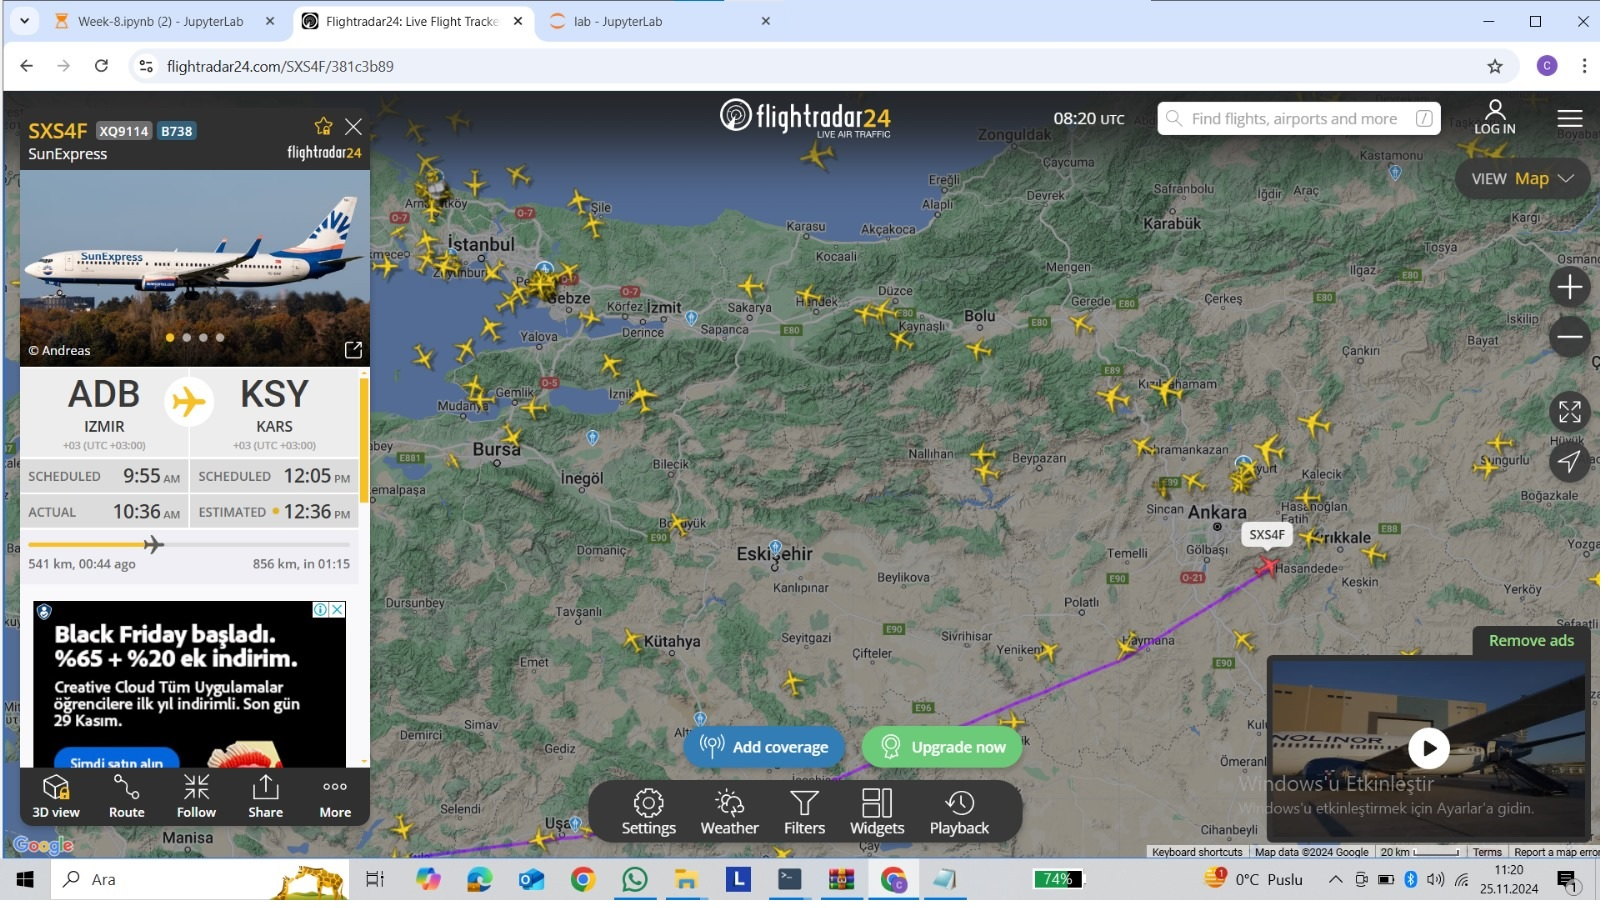

Type 4 olan Q2'de toplam 3, Q3'de ise6 tane ,Flight radarda ise çevremizde yaklaşık tahmini 8 uçak bulduk. SX4F uçağımız her üçü için de ortak bulundu. Sonuçlarının farklı olmasının sebebi rtl_adsb komutunun bu iş için özel olması ve flight radarı destekleyen bir çok vericinin olmasıdır.